# Stellar Coordinate Explorer - Aitoff Sky Maps: Equitorial vs Galactic

## Objective
Create a side-by-side full-sky Aitoff projection maps of the random sample of sources.

## Why this matters
- Different coordinate systems reveal different aspects of the sky.
- Radio astronomers often use Galactic coordinates which is aligned with the Milky Way.
- Optical astronomers and telescope pointing often use Equitorial coordinates.

## Datasets
- Input: `stars_with_galactic_coord_random.fits` (has `ra`, `dec`, `gal_l`, `gal_b`, `phot_g_mean_mag`)

## Goals for Today
- Load the random sample
- Prepare Equitorial coordinates: wrap RA to [-$\pi$, $\pi$] radians
- Prepare Galactic coordinates: wrap l to [-$\pi$, $\pi$] radians
- Create a figure with two Aitoff subplots side by side
- Colour points by magnitude (log stretch) in both maps
- Add grid lines and colourbar
- Write interpretation: do the two maps show different distribution?

## Checkpoint
- Table loaded
- Equitorial coordinates wrapped correctly
- Galactic coordinates wrapped correctly
- Side-by-side Aitoff plots generated
- Colourbar and grid lines present
- Markdown cell with observations

## Code

### 1. Setup and Loading

In [2]:
# import
from astropy.table import Table
import astropy.units as u
from astropy.coordinates import Longitude, Angle
from astropy.visualization import MinMaxInterval
import numpy as np
import matplotlib.colors as colors
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt

# Load data

table = Table.read('../../data/stars_with_galactic_coord_random.fits')
table.info()

<Table length=10000>
      name       dtype  unit    class     n_bad
--------------- ------- ---- ------------ -----
      source_id   int64            Column     0
             ra float64  deg       Column     0
            dec float64  deg       Column     0
          gal_l float64  deg       Column     0
          gal_b float64  deg       Column     0
       parallax float64  mas       Column     0
phot_g_mean_mag float32  mag       Column     0
          bp_rp float32  mag MaskedColumn    12


### Prepare coordinates for Aitoff
Now we wrap both equitorial _RA_ and galactic longitude _l_ to [-$180^{\circ}$, $180^{\circ}$] radians:

In [ ]:
# Equitorial
ra_wrapped = Angle(table["ra"]).wrap_at(180 * u.deg)
ra_rad = ra_wrapped.radian
dec_rad = Angle(table["dec"]).radian

# Galactic
l_wrapped = Longitude(table["gal_l"], wrap_angle=180 * u.deg)
l_rad = l_wrapped.radian
b_rad = Angle(table["gal_b"]).radian

# Define format for longitude coordinate tickers
def coordinate_ticks(x, pos):
    """
    Determines the string value that get's displayed at each tick
    
    x: tick value (int, float)
    pos: tick position (automatic)
    """    
    tick_val = Angle(-x * u.radian).wrap_at(360 * u.deg).degree
    return f"${tick_val:.0f}" + r"^{\circ}$"


## Side-by-side Aitoff subplots

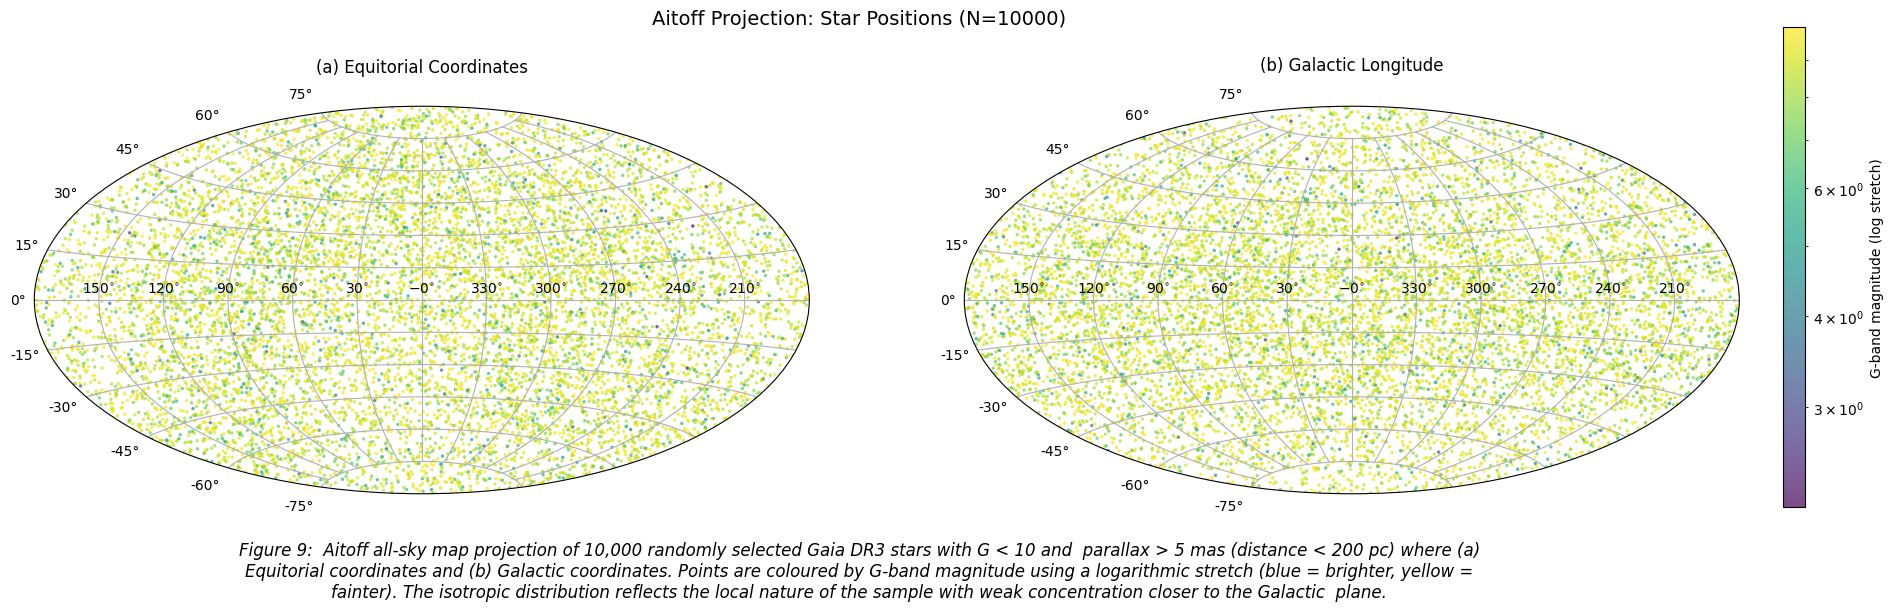

In [67]:

from mpl_toolkits.axes_grid1 import make_axes_locatable
import textwrap


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 6), subplot_kw={"projection": "aitoff"})
# Add axis positioned right of the second subplot for the colorbar
cb_ax = fig.add_axes([0.92, 0.15, 0.01, 0.8])

interval = MinMaxInterval()
min_G_mag, max_G_mag = interval.get_limits(table['phot_g_mean_mag'])

# Normalize using log stretch for magnitude color mapping
norm = colors.LogNorm(vmin=min_G_mag, vmax=max_G_mag)

# Equitorial Aitoff 
sc1 = ax1.scatter(-ra_rad, dec_rad, c=table['phot_g_mean_mag'], norm=norm, cmap='viridis', s=6, alpha=0.7, linewidths=0)
ax1.set_title("(a) Equitorial Coordinates", pad=25)
ax1.xaxis.set_major_formatter(FuncFormatter(coordinate_ticks))
ax1.grid(True)

# Galactic Aitoff
sc2 = ax2.scatter(-l_rad, b_rad, c=table['phot_g_mean_mag'], norm=norm, cmap='viridis', s=6, alpha=0.7, linewidths=0)
ax2.set_title("(b) Galactic Longitude", pad=26)
ax2.xaxis.set_major_formatter(FuncFormatter(coordinate_ticks))
ax2.grid(True)

# Add single colourbar for both
cbar = fig.colorbar(sc1, cax=cb_ax, orientation='vertical')
cbar.set_label('G-band magnitude (log stretch)')

fig_caption = """Figure 9:  Aitoff all-sky map projection of 10,000 randomly selected Gaia DR3 stars with G < 10 and 
parallax > 5 mas (distance < 200 pc) where (a) Equitorial coordinates and (b) Galactic coordinates. Points are coloured by G-band magnitude using a logarithmic
stretch (blue = brighter, yellow = fainter). The isotropic distribution reflects the local nature of the sample with weak concentration closer to the Galactic 
plane. 
"""
wrapper = textwrap.TextWrapper(width=150)
lines = wrapper.wrap(text=fig_caption)
fig_caption_wrapped = '\n'.join(lines)


plt.figtext(0.5, 0, fig_caption_wrapped, ha='center', fontsize=12, style='italic')
plt.suptitle(f"Aitoff Projection: Star Positions (N={len(table)})", fontsize=14)
plt.savefig('../../outputs/aitoff_projection_icrs_galactic_coord.png', dpi=300, bbox_inches='tight')
plt.show()


## Observation

- Both maps show a nearly uniform distribution of stars across the sky. 
-  No strong concentration toward the Galactic equator ($b = 0^{\circ}$) is visible.
-  The magnitude colouring appears relatively mixed across the sky.
  

## Interpretation
Unlike full-sky surveys containing large number of stars, this sample does not exhibit a larger concentration along the Galactic plane. This is due to the close proximity of the selected stars to the point of observation. Additionally, the magnitude variation gives no indication of spatial structure that is dependent on star brightness.